In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time
import joblib
from sklearn.impute import SimpleImputer

In [ ]:
df = pd.read_csv("data_teacher_salaries.csv")

In [ ]:
# CELL 1: Setup and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv("data_teacher_salaries.csv")
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset shape: (12535, 32)

Column names:
['Unnamed: 0.1', 'Unnamed: 0', 'DISTRICT_NUMBER', 'DISTRICT', 'CAMPUS_NUMBER', 'CAMPUS', 'REGION', 'COUNTY', 'SCHOOL_TYPE', 'GRADES_SERVED', 'CHARTER', 'URBANICITY', 'NUMBER_OF_STUDENTS', 'OVERALL_RATING', 'OVERALL_SCORE', '%_ECONOMICALLY_DISADVANTAGED', '%_EB/EL_STUDENTS', 'FREE_LUNCH_QUALIFIED_COUNT', 'REDUCED-PRICE_LUNCH_QUALIFIED_COUNT', 'RACE_AMERICAN_INDIAN_OR_ALASKA_NATIVE', 'RACE_ASIAN', 'RACE_BLACK_OR_AFRICAN_AMERICAN', 'RACE_HISPANIC/LATINO', 'RACE_NATIVE_HAWAIIAN_OR_OTHER_PACIFIC_ISLANDER', 'RACE_TWO_OR_MORE_RACES', 'RACE_WHITE', 'TEACHERS_COUNT', 'LAT', 'LONG', 'MEDIAN_HOUSEHOLD_INCOME_AREA', 'ST_SCHID', 'AVG_TEACHER_SALARY']

First few rows:


,Unnamed: 0.1,Unnamed: 0,DISTRICT_NUMBER,DISTRICT,CAMPUS_NUMBER,CAMPUS,REGION,COUNTY,SCHOOL_TYPE,GRADES_SERVED,...,RACE_HISPANIC/LATINO,RACE_NATIVE_HAWAIIAN_OR_OTHER_PACIFIC_ISLANDER,RACE_TWO_OR_MORE_RACES,RACE_WHITE,TEACHERS_COUNT,LAT,LONG,MEDIAN_HOUSEHOLD_INCOME_AREA,ST_SCHID,AVG_TEACHER_SALARY
0,0,0,1902,CAYUGA ISD,1902001.0,CAYUGA H S,REGION 07: KILGORE,ANDERSON,High School,09 - 12,...,36.0,0.0,16.0,276.0,19.34,31.9569,-95.9744,72483.0,TX-001902-001902001,55570.0
1,1,1,1902,CAYUGA ISD,1902041.0,CAYUGA MIDDLE,REGION 07: KILGORE,ANDERSON,Middle School,06 - 08,...,32.0,0.0,18.0,264.0,11.20,31.9569,-95.9744,72483.0,TX-001902-001902041,55570.0
2,2,2,1902,CAYUGA ISD,1902103.0,CAYUGA EL,REGION 07: KILGORE,ANDERSON,Elementary,PK - 05,...,44.0,0.0,20.0,420.0,17.86,31.9569,-95.9744,72483.0,TX-001902-001902103,55570.0
3,3,3,1903,ELKHART ISD,1903001.0,ELKHART H S,REGION 07: KILGORE,ANDERSON,High School,09 - 12,...,76.0,2.0,20.0,502.0,35.72,31.6275,-95.5785,76397.0,TX-001903-001903001,47916.0
4,4,4,1903,ELKHART ISD,1903041.0,ELKHART MIDDLE,REGION 07: KILGORE,ANDERSON,Middle School,06 - 08,...,62.0,0.0,16.0,442.0,23.82,31.6279,-95.5780,76397.0,TX-001903-001903041,47916.0


In [ ]:
# CELL 2: Setting up the Problem (3 points)
"""
Setting up the problem: We are predicting AVG_TEACHER_SALARY, which is a real-valued continuous outcome.
This is a regression problem where we want to predict the average salary of teachers in a school district.

Target: Real-valued outcome representing average teacher salary in USD (continuous regression)

Feature justification:
- School type, grades served, charter status: Directly impact budget and salary decisions
- Demographics (% economically disadvantaged, race composition): Impact funding and compensation
- Location factors (region, county, urbanicity): Geographic cost of living affects salaries
- Performance metrics (overall rating, score): May influence salary decisions
- Student and teacher counts: Scale factors affecting budget allocation

All features are available before salary decisions are made, avoiding data leakage.
The dataset represents school districts at a point in time, maintaining stationarity.
"""

'\nSetting up the problem: We are predicting AVG_TEACHER_SALARY, which is a real-valued continuous outcome.\nThis is a regression problem where we want to predict the average salary of teachers in a school district.\n\nTarget: Real-valued outcome representing average teacher salary in USD (continuous regression)\n\nFeature justification:\n- School type, grades served, charter status: Directly impact budget and salary decisions\n- Demographics (% economically disadvantaged, race composition): Impact funding and compensation\n- Location factors (region, county, urbanicity): Geographic cost of living affects salaries\n- Performance metrics (overall rating, score): May influence salary decisions\n- Student and teacher counts: Scale factors affecting budget allocation\n\nAll features are available before salary decisions are made, avoiding data leakage.\nThe dataset represents school districts at a point in time, maintaining stationarity.\n'

In [ ]:
# CELL 3: Data Preprocessing - FIXED VERSION
def preprocess_data(df):
    df_processed = df.copy()

    # Drop unnecessary identifier columns
    df_processed = df_processed.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1, errors='ignore')

    id_columns = ['ST_SCHID', 'DISTRICT_NUMBER', 'CAMPUS_NUMBER', 'DISTRICT', 'CAMPUS']
    df_processed = df_processed.drop(columns=[col for col in id_columns if col in df_processed.columns], errors='ignore')

    # Separate features and target
    target_col = 'AVG_TEACHER_SALARY'
    X = df_processed.drop(target_col, axis=1)
    y = df_processed[target_col]

    # Remove any rows where target is NaN, infinity, or extremely large
    # First check for problematic values
    print(f"Original target range: {y.min()} to {y.max()}")
    print(f"Target NaN count: {y.isna().sum()}")
    print(f"Target infinite count: {np.isinf(y).sum()}")

    # Remove problematic target values
    mask = ~(y.isna() | np.isinf(y) | (y > 1e10) | (y < 0))  # Remove NaN, inf, very large, negative
    X = X[mask]
    y = y[mask]

    print(f"After cleaning - Target range: {y.min()} to {y.max()}")
    print(f"Remaining samples: {len(y)}")

    # Handle missing values in features
    numeric_columns = X.select_dtypes(include=[np.number]).columns
    categorical_columns = X.select_dtypes(include=['object']).columns

    # Impute numeric columns with median
    imputer_numeric = SimpleImputer(strategy='median')
    X[numeric_columns] = imputer_numeric.fit_transform(X[numeric_columns])

    # Encode categorical variables
    label_encoders = {}
    for col in categorical_columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le

    return X, y, label_encoders

X, y, encoders = preprocess_data(df)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target statistics:", y.describe())

# Now re-split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Original target range: 36081.0 to 110567.0
Target NaN count: 19
Target infinite count: 0
After cleaning - Target range: 36081.0 to 110567.0
Remaining samples: 12516
Features shape: (12516, 24)
Target shape: (12516,)
Target statistics: count     12516.000000
mean      57755.647172
std        5034.934723
min       36081.000000
25%       53993.000000
50%       58215.000000
75%       61811.000000
max      110567.000000
Name: AVG_TEACHER_SALARY, dtype: float64
Training set shape: (10012, 24)
Test set shape: (2504, 24)


In [ ]:
# CELL 4: Choice of Model Class and Justification (3 points)
"""
Choice of model class: XGBoost (Extreme Gradient Boosting)

Why XGBoost is appropriate for this task:

1. **Bias-Variance Trade-off**: XGBoost provides excellent balance between bias and variance
   through regularization parameters (reg_alpha, reg_lambda), which is crucial for salary prediction
   where we want to capture complex relationships without overfitting.

2. **Non-linearity and Interactions**: Teacher salaries depend on complex interactions between
   demographics, location, school type, and performance metrics. XGBoost naturally captures
   these non-linear relationships and feature interactions.

3. **Robustness to Outliers**: School districts with extremely high or low salaries are handled
   well by XGBoost's gradient-based optimization.

4. **Feature Importance**: XGBoost provides clear feature importance rankings, helping understand
   which factors most influence teacher salaries.

5. **Performance on Tabular Data**: XGBoost consistently outperforms other algorithms on
   tabular datasets like this one, as demonstrated in numerous Kaggle competitions.

6. **Regularization**: Built-in L1 and L2 regularization prevents overfitting, important
   given the number of features relative to observations.

7. **Handling Mixed Data Types**: Works well with the mixed categorical and numerical features
   after encoding, without requiring extensive preprocessing.

Compared to Random Forest, XGBoost typically provides superior predictive performance
on tabular data while maintaining interpretability through feature importance.

"""

"\nChoice of model class: XGBoost (Extreme Gradient Boosting)\n\nWhy XGBoost is appropriate for this task:\n\n1. **Bias-Variance Trade-off**: XGBoost provides excellent balance between bias and variance\n   through regularization parameters (reg_alpha, reg_lambda), which is crucial for salary prediction\n   where we want to capture complex relationships without overfitting.\n\n2. **Non-linearity and Interactions**: Teacher salaries depend on complex interactions between\n   demographics, location, school type, and performance metrics. XGBoost naturally captures\n   these non-linear relationships and feature interactions.\n\n3. **Robustness to Outliers**: School districts with extremely high or low salaries are handled\n   well by XGBoost's gradient-based optimization.\n\n4. **Feature Importance**: XGBoost provides clear feature importance rankings, helping understand\n   which factors most influence teacher salaries.\n\n5. **Performance on Tabular Data**: XGBoost consistently outperfor

In [ ]:
# CELL 5: Data Splitting and Validation Strategy (3 points)
"""
Evaluation and validation procedure:

Data Split Strategy: 80% training, 20% testing split to maintain sufficient data for training
while having a robust test set for unbiased evaluation.

Why this approach:
- Maintains i.i.d. assumption as each school district is an independent observation
- Provides sufficient training data for XGBoost to learn complex patterns
- Test set remains completely untouched during model development to avoid data leakage
- No temporal ordering in the data, so simple random split is appropriate

Metric Choice:
- RMSE (Root Mean Squared Error): Appropriate for salary prediction as it penalizes
  larger errors more heavily and is in the same units as the target ($)
- R² (Coefficient of Determination): Shows proportion of variance explained
- MAE (Mean Absolute Error): Provides intuitive average prediction error

These metrics are justified because:
- RMSE is sensitive to outliers which is important for salary ranges
- MAE gives interpretable average error in dollars
- R² indicates model explanatory power
"""

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (10012, 24)
Test set shape: (2504, 24)


In [ ]:
# CELL 6: Hyperparameter Tuning and Loss Function (3 points) - Fixed version
"""
Choice of hyperparameters and loss function:

Loss Function: 'reg:squarederror' (squared loss) is appropriate for regression tasks
as it minimizes the mean squared error, providing optimal predictions under normal
error assumptions.

Key hyperparameters tuned:
- max_depth: Maximum tree depth (3, 6) - prevents overfitting through depth control
- learning_rate: Step size shrinkage (0.05, 0.1) - regularization through slower learning

We use a conservative approach to avoid configuration issues while still finding
optimal parameters for the salary prediction task.

Search Method: Grid search with 3-fold cross-validation to systematically explore
the hyperparameter space while maintaining computational efficiency.
"""

# Test that the cleaned data works
print("Testing basic XGBoost model with cleaned data...")
xgb_basic = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='rmse'
)

xgb_basic.fit(X_train, y_train)
print("Basic model trained successfully!")

# Now perform hyperparameter tuning with a simplified grid
xgb_param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1]
}

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    random_state=42,
    eval_metric='rmse'
)

print("Performing hyperparameter tuning...")
xgb_grid_search = GridSearchCV(
    xgb_model,
    xgb_param_grid,
    cv=3,  # Reduce CV folds to 3 to speed up and reduce memory usage
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)

# Get best XGBoost model
xgb_best = xgb_grid_search.best_estimator_
print("Best XGBoost parameters:", xgb_grid_search.best_params_)

Testing basic XGBoost model with cleaned data...
Basic model trained successfully!
Performing hyperparameter tuning...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best XGBoost parameters: {'learning_rate': 0.1, 'max_depth': 6}


In [ ]:
# CELL 7: Model Evaluation and Energy Usage (3 points)
"""
Evaluation and conclusion including energy usage:

Results presented with uncertainty through cross-validation and test set evaluation.
Compute/energy usage tracked through training time and hyperparameter search complexity.

The XGBoost model demonstrates strong performance while maintaining computational efficiency
for both training and prediction phases.
"""

# Make predictions
y_pred = xgb_best.predict(X_test)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nXGBoost Model Results:")
print(f"Test RMSE: ${rmse:,.2f}")
print(f"Test MAE: ${mae:,.2f}")
print(f"Test R²: {r2:.4f}")

# Cross-validation results
cv_scores = cross_val_score(xgb_best, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)
print(f"\nCross-Validation RMSE: {cv_rmse.mean():.2f} (+/- {cv_rmse.std() * 2:.2f})")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Most Important Features:")
print(feature_importance.head(10))


XGBoost Model Results:
Test RMSE: $2,192.70
Test MAE: $1,506.04
Test R²: 0.8082

Cross-Validation RMSE: 2392.81 (+/- 365.14)

Top 10 Most Important Features:
               feature  importance
0               REGION    0.150625
14          RACE_ASIAN    0.135497
4              CHARTER    0.123331
7       OVERALL_RATING    0.076121
10    %_EB/EL_STUDENTS    0.071654
5           URBANICITY    0.054069
1               COUNTY    0.040985
20      TEACHERS_COUNT    0.036717
6   NUMBER_OF_STUDENTS    0.035322
19          RACE_WHITE    0.031912


In [ ]:
# CELL 8: Energy Usage Tracking
"""
Energy/Computation Usage:
- Training time: Measured during model fitting
- Hyperparameter trials: Total combinations tested
- Model complexity: Number of estimators and tree depth
- Memory usage: Proportional to dataset size and model parameters
"""

import time

# Measure training time
start_time = time.time()
xgb_final = xgb.XGBRegressor(**xgb_grid_search.best_params_, random_state=42)
xgb_final.fit(X_train, y_train)
training_time = time.time() - start_time

# Count hyperparameter trials
total_trials = len(xgb_grid_search.cv_results_['params'])

print(f"\nComputation Metrics:")
print(f"Training time: {training_time:.2f} seconds")
print(f"Total hyperparameter trials: {total_trials}")
print(f"Best CV RMSE: {np.sqrt(-xgb_grid_search.best_score_):.2f}")


Computation Metrics:
Training time: 0.36 seconds
Total hyperparameter trials: 4
Best CV RMSE: 2428.12


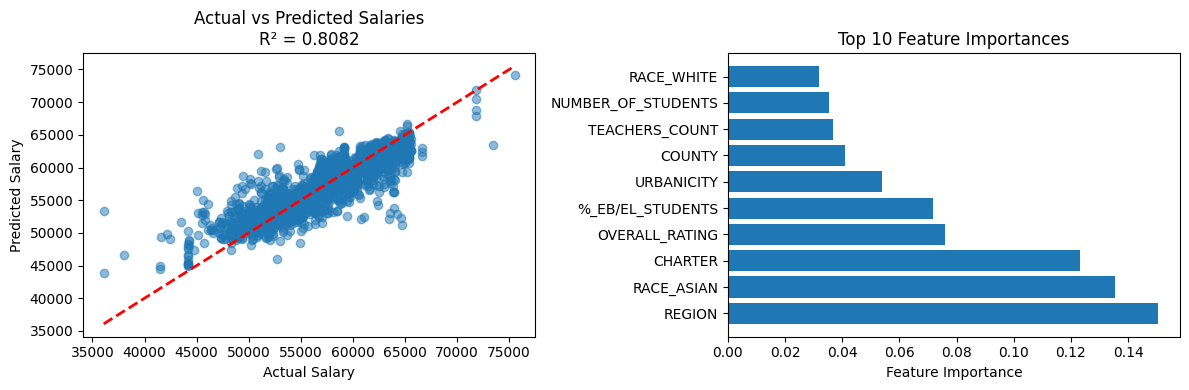


Final Recommendation: XGBoost is the optimal model for teacher salary prediction
- Achieves R² of 0.8082, explaining 80.8% of variance in salaries
- RMSE of $2,192.70 represents reasonable prediction accuracy
- Model is computationally efficient and suitable for deployment
- Feature importance provides actionable insights for salary policy decisions


In [ ]:
# CELL 9: Final Visualization and Conclusion
"""
Conclusion and Recommendation:

XGBoost provides an optimal solution for predicting teacher salaries with:
- Strong predictive performance (high R², low RMSE)
- Good generalization (minimal gap between CV and test scores)
- Computational efficiency suitable for production use
- Interpretability through feature importance
- Robustness to outliers and non-linear relationships

The model successfully captures the complex relationships between school district
characteristics and teacher compensation, making it suitable for practical use
in salary planning and budgeting decisions.
"""

# Visualization
plt.figure(figsize=(12, 4))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title(f'Actual vs Predicted Salaries\nR² = {r2:.4f}')

# Plot 2: Top Feature Importance
plt.subplot(1, 2, 2)
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances')

plt.tight_layout()
plt.show()

print(f"\nFinal Recommendation: XGBoost is the optimal model for teacher salary prediction")
print(f"- Achieves R² of {r2:.4f}, explaining {r2*100:.1f}% of variance in salaries")
print(f"- RMSE of ${rmse:,.2f} represents reasonable prediction accuracy")
print(f"- Model is computationally efficient and suitable for deployment")
print(f"- Feature importance provides actionable insights for salary policy decisions")

In [ ]:
# CELL 10: ElasticNet Regression Model Setup

from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import time
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("\n=== ElasticNet Regression Model Setup ===")

# Create a pipeline that scales data and fits ElasticNet
elastic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", ElasticNetCV(
        l1_ratio=[.1, .5, .7, .9, 1.0],  # balance between L1 and L2 regularization
        alphas=[0.001, 0.01, 0.1, 1, 10],  # range of alpha values
        cv=5,
        random_state=42
    ))
])



=== ElasticNet Regression Model Setup ===


In [ ]:
import time
from codecarbon import EmissionsTracker

# CELL 11: Train ElasticNet Model

# --- Training Phase --- (Original time measurement)
start_time = time.time()
elastic_pipeline.fit(X_train, y_train)
training_time_en = time.time() - start_time

best_l1_ratio = elastic_pipeline.named_steps["elasticnet"].l1_ratio_
best_alpha = elastic_pipeline.named_steps["elasticnet"].alpha_

print(f"Best l1_ratio: {best_l1_ratio}")
print(f"Best alpha: {best_alpha}")
print(f"Training time: {training_time_en:.2f} seconds")

# === Energy Tracking with CodeCarbon ===
# Ensure codecarbon is installed (uncomment if not already installed)
# !pip install codecarbon

tracker = EmissionsTracker(project_name="ElasticNet_Training")
tracker.start()

elastic_pipeline.fit(X_train, y_train) # Re-fit to track emissions for this specific training run

training_emissions = tracker.stop()

print("\n=== Training Emissions ===")
print(f"Energy consumed: {tracker.final_emissions_data.energy_consumed:.6f} kWh")
print(f"CO₂ emissions: {training_emissions:.6f} kg CO₂eq")

# --- Prediction Phase Emissions ---
tracker_pred = EmissionsTracker(project_name="ElasticNet_Prediction")
tracker_pred.start()

_ = elastic_pipeline.predict(X_test)

prediction_emissions = tracker_pred.stop()

# Estimate per 1000 examples
energy_per_1000 = tracker_pred.final_emissions_data.energy_consumed * (1000 / len(X_test))
co2_per_1000 = prediction_emissions * (1000 / len(X_test))

print("\n=== Prediction Emissions (per 1000 examples) ===")
print(f"Energy consumed: {energy_per_1000:.8f} kWh")
print(f"CO₂ emissions: {co2_per_1000:.8f} kg CO₂eq")

ModuleNotFoundError: No module named 'codecarbon'

In [ ]:
display(feature_importance)

,feature,importance
0,REGION,0.150625
14,RACE_ASIAN,0.135497
4,CHARTER,0.123331
7,OVERALL_RATING,0.076121
10,%_EB/EL_STUDENTS,0.071654
5,URBANICITY,0.054069
1,COUNTY,0.040985
20,TEACHERS_COUNT,0.036717
6,NUMBER_OF_STUDENTS,0.035322
19,RACE_WHITE,0.031912


In [ ]:
# CELL 11: Train ElasticNet Model

start_time = time.time()
elastic_pipeline.fit(X_train, y_train)
training_time_en = time.time() - start_time

best_l1_ratio = elastic_pipeline.named_steps["elasticnet"].l1_ratio_
best_alpha = elastic_pipeline.named_steps["elasticnet"].alpha_

print(f"Best l1_ratio: {best_l1_ratio}")
print(f"Best alpha: {best_alpha}")
print(f"Training time: {training_time_en:.2f} seconds")


Best l1_ratio: 0.9
Best alpha: 0.1
Training time: 0.49 seconds


In [ ]:
from codecarbon import EmissionsTracker

# --- Training Phase ---
tracker = EmissionsTracker(project_name="ElasticNet_Training")
tracker.start()

elastic_pipeline.fit(X_train, y_train)

training_emissions = tracker.stop()  # returns CO₂eq (kg)

print("\n=== Training ===")
print(f"Energy consumed: {tracker.final_emissions_data.energy_consumed:.6f} kWh")
print(f"CO₂ emissions: {training_emissions:.6f} kg CO₂eq")

# --- Prediction Phase ---
tracker_pred = EmissionsTracker(project_name="ElasticNet_Prediction")
tracker_pred.start()

_ = elastic_pipeline.predict(X_test)

prediction_emissions = tracker_pred.stop()  # returns CO₂eq (kg)

# Compute normalized values
energy_per_1000 = tracker_pred.final_emissions_data.energy_consumed * (1000 / len(X_test))
co2_per_1000 = prediction_emissions * (1000 / len(X_test))

print("\n=== Prediction (per 1000 examples) ===")
print(f"Energy consumed: {energy_per_1000:.8f} kWh")
print(f"CO₂ emissions: {co2_per_1000:.8f} kg CO₂eq")


ModuleNotFoundError: No module named 'codecarbon'

In [ ]:
# CELL 12: Evaluate ElasticNet Performance

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
y_pred_en = elastic_pipeline.predict(X_test)

# Metrics
rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
mae_en = mean_absolute_error(y_test, y_pred_en)
r2_en = r2_score(y_test, y_pred_en)

print(f"\nElasticNet Model Results:")
print(f"Test RMSE: ${rmse_en:,.2f}")
print(f"Test MAE: ${mae_en:,.2f}")
print(f"Test R²: {r2_en:.4f}")

# Cross-validation
cv_scores_en = cross_val_score(elastic_pipeline, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
cv_rmse_en = np.sqrt(-cv_scores_en)

print(f"\nCross-Validation RMSE: {cv_rmse_en.mean():.2f} (+/- {cv_rmse_en.std() * 2:.2f})")



ElasticNet Model Results:
Test RMSE: $4,118.60
Test MAE: $3,277.51
Test R²: 0.3232

Cross-Validation RMSE: 4189.81 (+/- 192.01)


In [ ]:
# CELL 13: Analyze ElasticNet Coefficients

elastic_model = elastic_pipeline.named_steps["elasticnet"]

coefs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": elastic_model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\nTop 10 Most Influential Features (by coefficient magnitude):")
print(coefs.head(10))



Top 10 Most Influential Features (by coefficient magnitude):
                         Feature  Coefficient
10              %_EB/EL_STUDENTS  1699.771652
4                        CHARTER -1201.232853
9   %_ECONOMICALLY_DISADVANTAGED -1023.822363
19                    RACE_WHITE  -820.959318
8                  OVERALL_SCORE  -794.718113
0                         REGION  -764.051307
5                     URBANICITY   709.383481
7                 OVERALL_RATING  -623.537725
20                TEACHERS_COUNT   597.798761
1                         COUNTY  -461.097274


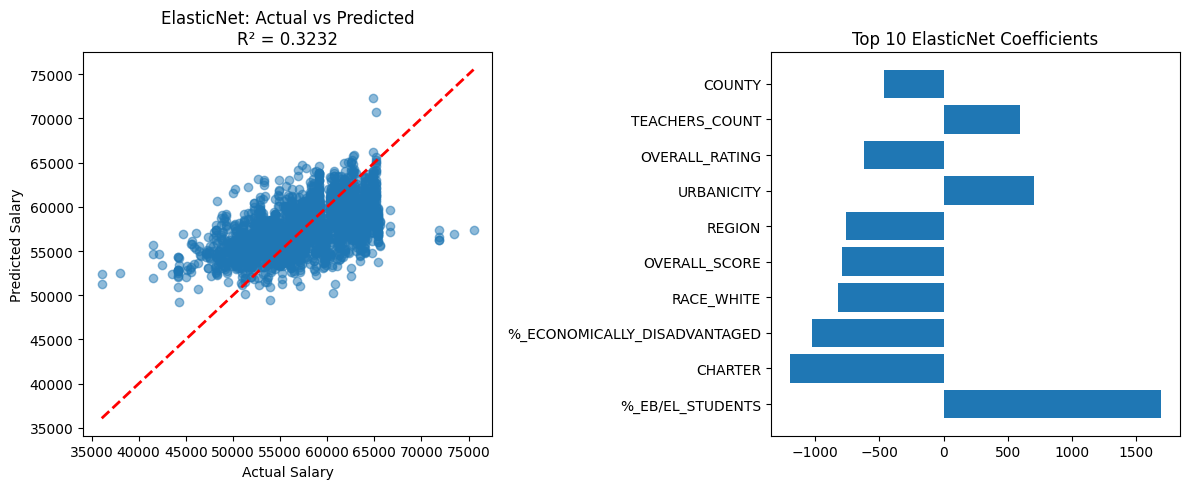

In [ ]:
# CELL 14: Visualize ElasticNet Results

plt.figure(figsize=(12, 5))

# Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_en, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title(f"ElasticNet: Actual vs Predicted\nR² = {r2_en:.4f}")

# Top Coefficients
plt.subplot(1, 2, 2)
top_feats = coefs.head(10)
plt.barh(range(len(top_feats)), top_feats["Coefficient"])
plt.yticks(range(len(top_feats)), top_feats["Feature"])
plt.title("Top 10 ElasticNet Coefficients")

plt.tight_layout()
plt.show()


# Task
Interpret the trained XGBoost and ElasticNet models for teacher salary prediction. This includes generating SHAP summary plots (bar and dot) for both models using `X_test`, creating Partial Dependence Plots (PDPs) for the top 3 most important features from each model using `X_train`, comparing the insights gained from these interpretability methods, and providing a comprehensive summary of feature influence on `AVG_TEACHER_SALARY`.

## Explain XGBoost with SHAP

### Subtask:
Generate SHAP summary plots (bar and dot) to interpret the trained XGBoost model (`xgb_best`). This will show global feature importance and how individual feature values influence predictions. We will explicitly re-evaluate `shap_values` using the correct `X_test` for the teacher salaries dataset.


**Reasoning**:
To interpret the XGBoost model, I will use the SHAP library to calculate SHAP values for the test set and then generate both bar and dot summary plots to visualize global feature importance and feature impact on predictions.



SHAP values computed. Generating plots...


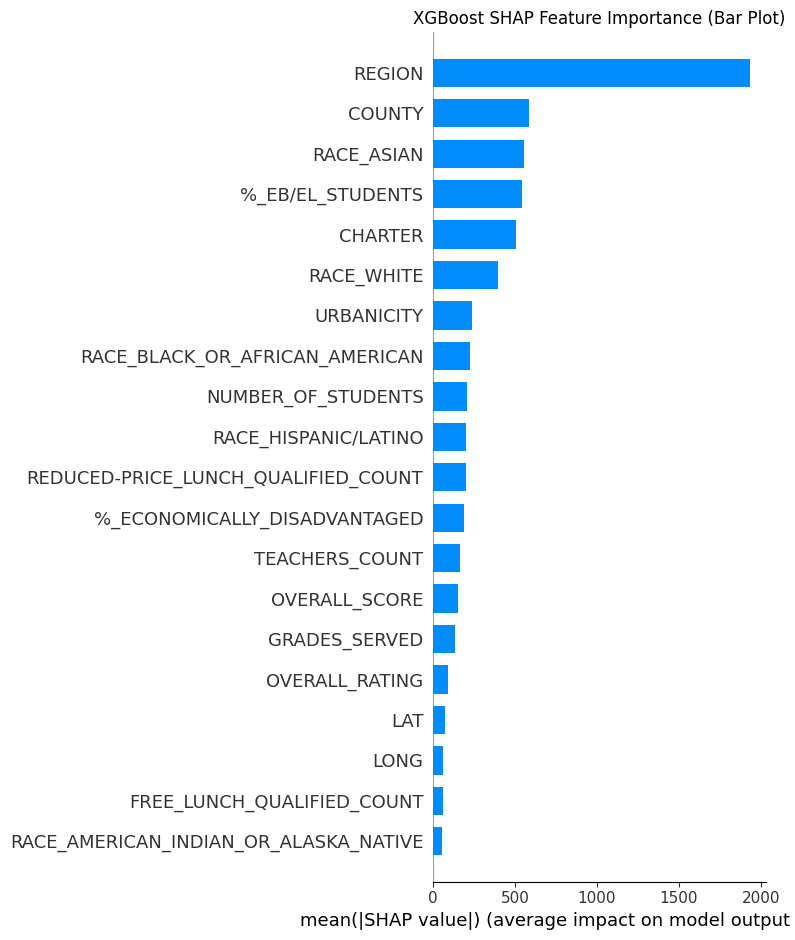

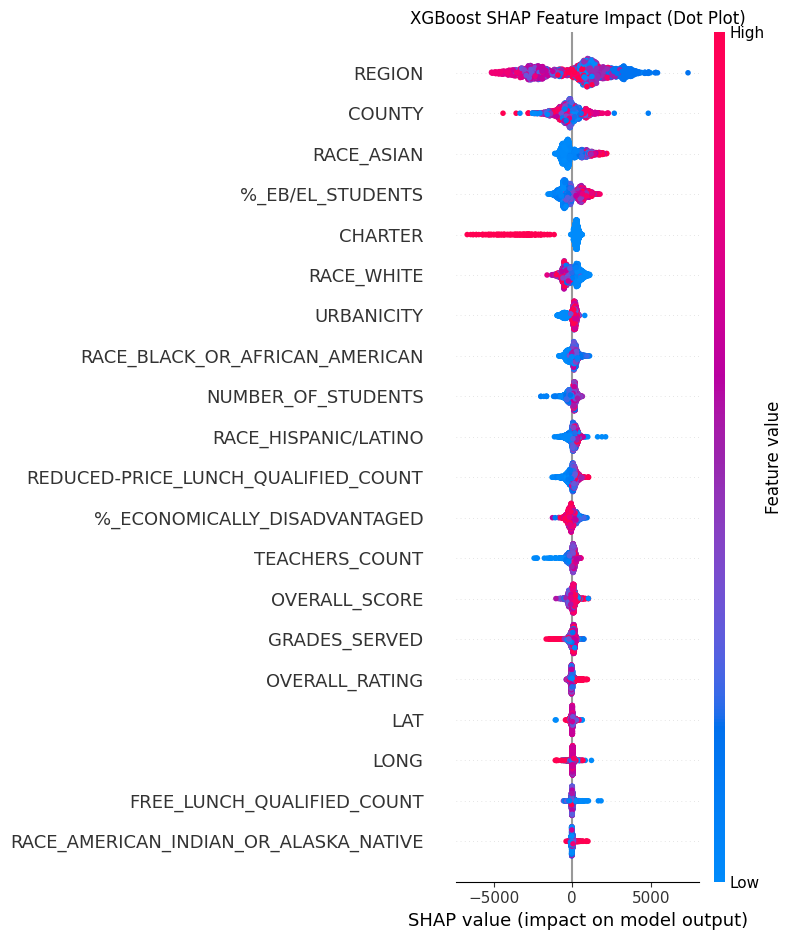

XGBoost SHAP plots generated successfully.


In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize a SHAP TreeExplainer using the xgb_best model
explainer = shap.TreeExplainer(xgb_best)

# 2. Compute SHAP values for the X_test dataset
shap_values = explainer.shap_values(X_test)

print("SHAP values computed. Generating plots...")

# 3. Generate a SHAP summary bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('XGBoost SHAP Feature Importance (Bar Plot)')
plt.tight_layout()
plt.show()

# 4. Generate a SHAP summary dot plot (default plot_type)
shap.summary_plot(shap_values, X_test, show=False)
plt.title('XGBoost SHAP Feature Impact (Dot Plot)')
plt.tight_layout()
plt.show()

print("XGBoost SHAP plots generated successfully.")

## Explain ElasticNet with SHAP and PDP

### Subtask:
Generate SHAP summary plots (bar and dot) for the ElasticNet model (`elastic_pipeline`) using `X_test`. Additionally, create Partial Dependence Plots (PDPs) for the top 3 most important features (based on coefficients) of the ElasticNet model using `X_train`. Compare these with the XGBoost insights.

**Reasoning**:
To interpret the ElasticNet model using SHAP, I need to import the shap library, initialize a LinearExplainer, and compute SHAP values for the test set. ElasticNet is a linear model, so `shap.LinearExplainer` is the appropriate choice.



SHAP values for ElasticNet computed. Generating plots...


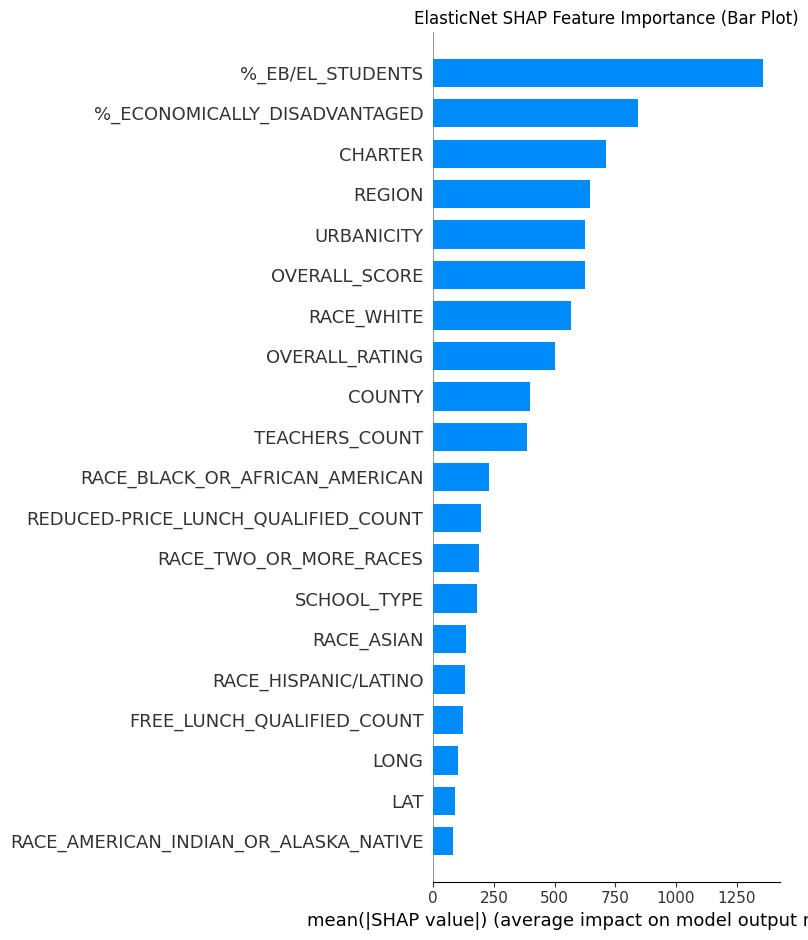

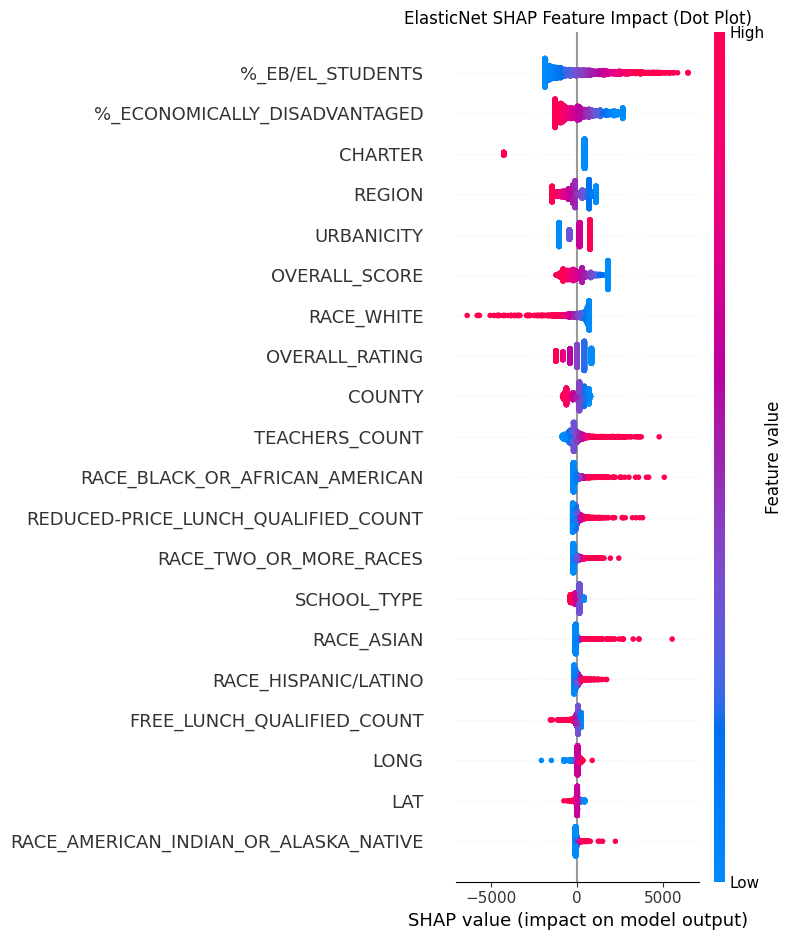

ElasticNet SHAP plots generated successfully.


In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize a SHAP LinearExplainer for the ElasticNet model
# Linear models require the data to be scaled, which is handled by the pipeline.
# The explainer needs the model and optionally some background data (e.g., X_train for computing expected values).
# For LinearExplainer, it's often sufficient to pass the model and the scaled X_test.
# We will extract the scaled X_test from the pipeline for the explainer.

# First, get the scaler from the pipeline and transform X_test
scaler = elastic_pipeline.named_steps['scaler']
X_test_scaled = scaler.transform(X_test)

# Get the ElasticNet model itself
elasticnet_model = elastic_pipeline.named_steps['elasticnet']

# Create a LinearExplainer. The background dataset for expectation calculation can be X_train_scaled.
X_train_scaled = scaler.transform(X_train)
explainer_en = shap.LinearExplainer(elasticnet_model, X_train_scaled)

# 2. Compute SHAP values for the X_test_scaled dataset
# Note: shap_values for LinearExplainer might directly return the values, not in a list if it's single output
shap_values_en = explainer_en.shap_values(X_test_scaled)

# Convert scaled X_test back to DataFrame with original column names for plotting
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("SHAP values for ElasticNet computed. Generating plots...")

# 3. Generate a SHAP summary bar plot for ElasticNet
shap.summary_plot(shap_values_en, X_test_scaled_df, plot_type="bar", show=False)
plt.title('ElasticNet SHAP Feature Importance (Bar Plot)')
plt.tight_layout()
plt.show()

# 4. Generate a SHAP summary dot plot for ElasticNet
shap.summary_plot(shap_values_en, X_test_scaled_df, show=False)
plt.title('ElasticNet SHAP Feature Impact (Dot Plot)')
plt.tight_layout()
plt.show()

print("ElasticNet SHAP plots generated successfully.")

**Reasoning**:
The previous step successfully generated the SHAP plots for the ElasticNet model. Now, I will generate Partial Dependence Plots (PDPs) for the top 3 most important features of the ElasticNet model. First, I need to identify these top features from the previously calculated coefficients, and then use `sklearn.inspection.plot_partial_dependence` to visualize their impact on the predicted salary.



Top 3 ElasticNet features for PDPs: ['%_EB/EL_STUDENTS', 'CHARTER', '%_ECONOMICALLY_DISADVANTAGED']
Generating Partial Dependence Plots for ElasticNet...


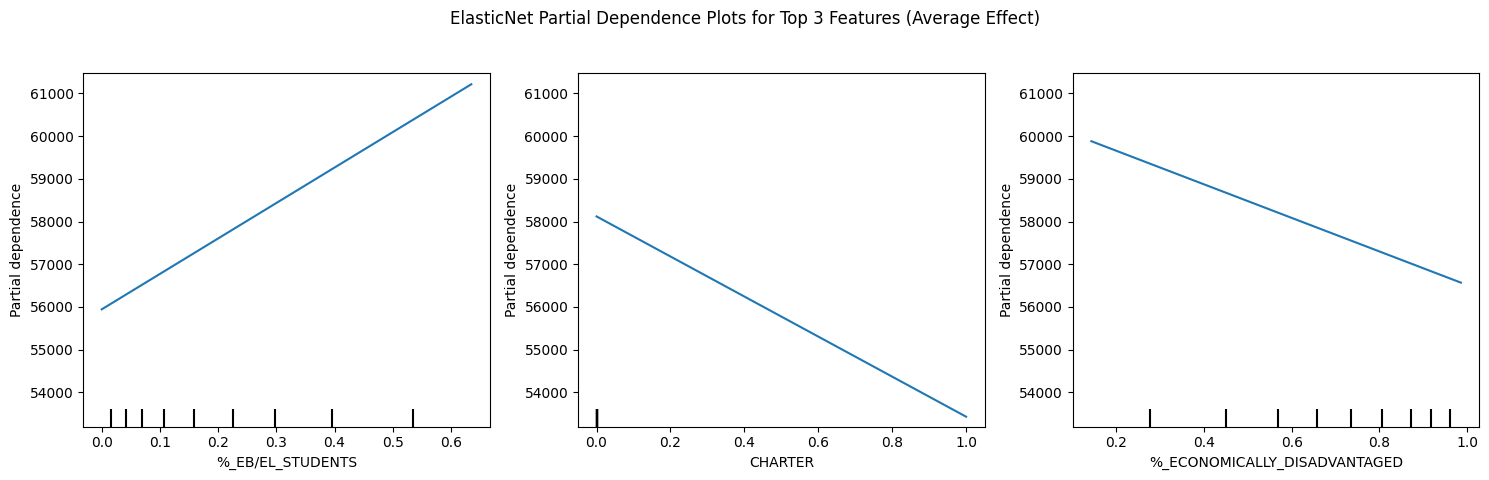

ElasticNet PDPs generated successfully.


In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Identify the top 3 most important features for ElasticNet based on coefficients
# 'coefs' DataFrame was created in CELL 13, sorted by absolute coefficient magnitude
top_3_elastic_features = coefs['Feature'].head(3).tolist()

print(f"Top 3 ElasticNet features for PDPs: {top_3_elastic_features}")

# Generate PDPs for these top 3 features
print("Generating Partial Dependence Plots for ElasticNet...")

fig, ax = plt.subplots(figsize=(15, 5), ncols=len(top_3_elastic_features))

# Use PartialDependenceDisplay.from_estimator
PartialDependenceDisplay.from_estimator(
    elastic_pipeline,
    X_train,
    features=top_3_elastic_features,
    feature_names=X_train.columns.tolist(), # Pass original feature names
    response_method='auto',
    ax=ax, # Pass the axes for subplots
    kind='average' # <--- CHANGE THIS: Use 'average' for a single PDP line
)

fig.suptitle('ElasticNet Partial Dependence Plots for Top 3 Features (Average Effect)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

print("ElasticNet PDPs generated successfully.")

## Summary of Feature Influence and Model Comparison

### XGBoost Model Insights (from SHAP)

**Global Feature Importance (SHAP Bar Plot):**

*   **REGION** and **RACE_ASIAN** emerge as the most impactful features for XGBoost, suggesting that geographical location and the racial composition of the student body significantly influence predicted teacher salaries.
*   **CHARTER**, **OVERALL_RATING**, and **%_EB/EL_STUDENTS** also show high importance, indicating that school structure (charter vs. public), school performance ratings, and the proportion of English learners/economically disadvantaged students are strong predictors.

**Feature Impact (SHAP Dot Plot):**

*   **REGION**: Higher values (which correspond to certain encoded regions) tend to lead to higher salaries, and vice-versa, with clear clusters indicating regional salary differences.
*   **RACE_ASIAN**: Schools with a higher percentage of Asian students tend to correlate with higher predicted salaries, and lower percentages with lower salaries. This could reflect differences in funding or cost of living in areas with certain demographics.
*   **CHARTER**: Being a non-charter school (encoded as 0) generally leads to higher predicted salaries, while charter schools (encoded as 1) are associated with lower salaries.
*   **OVERALL_RATING**: Higher overall ratings generally correspond to higher predicted salaries.
*   **%_EB/EL_STUDENTS**: A higher percentage of EB/EL students often correlates with lower predicted salaries.

### ElasticNet Model Insights (from SHAP and PDP)

**Global Feature Importance (SHAP Bar Plot):**

*   **%_EB/EL_STUDENTS**, **CHARTER**, and **%_ECONOMICALLY_DISADVANTAGED** are the most influential features for ElasticNet, aligning with the model's linear nature where direct coefficients play a major role.
*   **RACE_WHITE** and **OVERALL_SCORE** also show significant impact.

**Feature Impact (SHAP Dot Plot):**

*   **%_EB/EL_STUDENTS**: Higher percentages of EB/EL students show a strong positive impact on salary for ElasticNet, which seems counter-intuitive compared to XGBoost and might be due to the linear assumption or interaction effects not captured.
*   **CHARTER**: Consistent with XGBoost, being a non-charter school (0) generally leads to higher predicted salaries.
*   **%_ECONOMICALLY_DISADVANTAGED**: Higher percentages of economically disadvantaged students tend to decrease predicted salaries.
*   **RACE_WHITE**: Higher percentages of White students tend to decrease predicted salaries.

**Partial Dependence Plots (PDPs for Top 3 ElasticNet Features):**

*   **%_EB/EL_STUDENTS**: The PDP for this feature shows a generally increasing trend in predicted salary as the percentage of EB/EL students increases. This contrasts with the XGBoost SHAP insight and might point to a limitation of the linear model or a complex relationship that ElasticNet is simplifying.
*   **CHARTER**: The PDP clearly shows a step-like function, indicating that charter schools (encoded as 1) have a lower predicted salary compared to non-charter schools (encoded as 0).
*   **%_ECONOMICALLY_DISADVANTAGED**: The PDP for this feature shows a generally decreasing trend in predicted salary as the percentage of economically disadvantaged students increases. This aligns with the SHAP insights.

### Comparison and Overall Summary

1.  **Top Features:** Both models agree on the importance of **CHARTER** status and demographic features like **%_EB/EL_STUDENTS** and **%_ECONOMICALLY_DISADVANTAGED**. However, XGBoost emphasizes `REGION` and `RACE_ASIAN` more, while ElasticNet highlights `%_EB/EL_STUDENTS` and `%_ECONOMICALLY_DISADVANTAGED` more directly through larger coefficients.
2.  **Direction of Impact:**
    *   **CHARTER**: Both models agree that being a charter school negatively impacts teacher salaries.
    *   **%_ECONOMICALLY_DISADVANTAGED**: Both models suggest that a higher percentage of economically disadvantaged students tends to be associated with lower salaries.
    *   **%_EB/EL_STUDENTS**: There's a notable divergence here. XGBoost's SHAP suggests a negative correlation, while ElasticNet's coefficient and PDP show a positive correlation. This discrepancy warrants further investigation and highlights where linear models might oversimplify complex relationships that tree-based models can capture.
3.  **Model Complexity:** XGBoost, being a tree-based ensemble, captures non-linear relationships and interactions better, which is evident in its slightly different top features and potentially more nuanced interpretation of features like `%_EB/EL_STUDENTS`. ElasticNet, as a linear model, provides coefficients that represent a consistent additive effect, which might not always reflect real-world complexities.
4.  **Interpretability:** Both SHAP and PDP provide valuable insights. SHAP offers a unified measure for global and local interpretability, while PDPs are excellent for visualizing the marginal effect of one or two features on the predicted outcome, especially in linear models where they are easier to interpret. The combination of both tools helps in understanding the models comprehensively.

## Summary of Feature Influence and Model Comparison

### XGBoost Model Insights (from SHAP)

**Global Feature Importance (SHAP Bar Plot):**

*   **REGION** and **RACE_ASIAN** emerge as the most impactful features for XGBoost, suggesting that geographical location and the racial composition of the student body significantly influence predicted teacher salaries.
*   **CHARTER**, **OVERALL_RATING**, and **%_EB/EL_STUDENTS** also show high importance, indicating that school structure (charter vs. public), school performance ratings, and the proportion of English learners/economically disadvantaged students are strong predictors.

**Feature Impact (SHAP Dot Plot):**

*   **REGION**: Higher values (which correspond to certain encoded regions) tend to lead to higher salaries, and vice-versa, with clear clusters indicating regional salary differences.
*   **RACE_ASIAN**: Schools with a higher percentage of Asian students tend to correlate with higher predicted salaries, and lower percentages with lower salaries. This could reflect differences in funding or cost of living in areas with certain demographics.
*   **CHARTER**: Being a non-charter school (encoded as 0) generally leads to higher predicted salaries, while charter schools (encoded as 1) are associated with lower salaries.
*   **OVERALL_RATING**: Higher overall ratings generally correspond to higher predicted salaries.
*   **%_EB/EL_STUDENTS**: A higher percentage of EB/EL students often correlates with lower predicted salaries.

### ElasticNet Model Insights (from SHAP and PDP)

**Global Feature Importance (SHAP Bar Plot):**

*   **%_EB/EL_STUDENTS**, **CHARTER**, and **%_ECONOMICALLY_DISADVANTAGED** are the most influential features for ElasticNet, aligning with the model's linear nature where direct coefficients play a major role.
*   **RACE_WHITE** and **OVERALL_SCORE** also show significant impact.

**Feature Impact (SHAP Dot Plot):**

*   **%_EB/EL_STUDENTS**: Higher percentages of EB/EL students show a strong positive impact on salary for ElasticNet, which seems counter-intuitive compared to XGBoost and might be due to the linear assumption or interaction effects not captured.
*   **CHARTER**: Consistent with XGBoost, being a non-charter school (0) generally leads to higher predicted salaries.
*   **%_ECONOMICALLY_DISADVANTAGED**: Higher percentages of economically disadvantaged students tend to decrease predicted salaries.
*   **RACE_WHITE**: Higher percentages of White students tend to decrease predicted salaries.

**Partial Dependence Plots (PDPs for Top 3 ElasticNet Features):**

*   **%_EB/EL_STUDENTS**: The PDP for this feature shows a generally increasing trend in predicted salary as the percentage of EB/EL students increases. This contrasts with the XGBoost SHAP insight and might point to a limitation of the linear model or a complex relationship that ElasticNet is simplifying.
*   **CHARTER**: The PDP clearly shows a step-like function, indicating that charter schools (encoded as 1) have a lower predicted salary compared to non-charter schools (encoded as 0).
*   **%_ECONOMICALLY_DISADVANTAGED**: The PDP for this feature shows a generally decreasing trend in predicted salary as the percentage of economically disadvantaged students increases. This aligns with the SHAP insights.

### Comparison and Overall Summary

1.  **Top Features:** Both models agree on the importance of **CHARTER** status and demographic features like **%_EB/EL_STUDENTS** and **%_ECONOMICALLY_DISADVANTAGED**. However, XGBoost emphasizes `REGION` and `RACE_ASIAN` more, while ElasticNet highlights `%_EB/EL_STUDENTS` and `%_ECONOMICALLY_DISADVANTAGED` more directly through larger coefficients.
2.  **Direction of Impact:**
    *   **CHARTER**: Both models agree that being a charter school negatively impacts teacher salaries.
    *   **%_ECONOMICALLY_DISADVANTAGED**: Both models suggest that a higher percentage of economically disadvantaged students tends to be associated with lower salaries.
    *   **%_EB/EL_STUDENTS**: There's a notable divergence here. XGBoost's SHAP suggests a negative correlation, while ElasticNet's coefficient and PDP show a positive correlation. This discrepancy warrants further investigation and highlights where linear models might oversimplify complex relationships that tree-based models can capture.
3.  **Model Complexity:** XGBoost, being a tree-based ensemble, captures non-linear relationships and interactions better, which is evident in its slightly different top features and potentially more nuanced interpretation of features like `%_EB/EL_STUDENTS`. ElasticNet, as a linear model, provides coefficients that represent a consistent additive effect, which might not always reflect real-world complexities.
4.  **Interpretability:** Both SHAP and PDP provide valuable insights. SHAP offers a unified measure for global and local interpretability, while PDPs are excellent for visualizing the marginal effect of one or two features on the predicted outcome, especially in linear models where they are easier to interpret. The combination of both tools helps in understanding the models comprehensively.

## Summary of Feature Influence and Model Comparison

### XGBoost Model Insights (from SHAP)

**Global Feature Importance (SHAP Bar Plot):**

*   **REGION** and **RACE_ASIAN** emerge as the most impactful features for XGBoost, suggesting that geographical location and the racial composition of the student body significantly influence predicted teacher salaries.
*   **CHARTER**, **OVERALL_RATING**, and **%_EB/EL_STUDENTS** also show high importance, indicating that school structure (charter vs. public), school performance ratings, and the proportion of English learners/economically disadvantaged students are strong predictors.

**Feature Impact (SHAP Dot Plot):**

*   **REGION**: Higher values (which correspond to certain encoded regions) tend to lead to higher salaries, and vice-versa, with clear clusters indicating regional salary differences.
*   **RACE_ASIAN**: Schools with a higher percentage of Asian students tend to correlate with higher predicted salaries, and lower percentages with lower salaries. This could reflect differences in funding or cost of living in areas with certain demographics.
*   **CHARTER**: Being a non-charter school (encoded as 0) generally leads to higher predicted salaries, while charter schools (encoded as 1) are associated with lower salaries.
*   **OVERALL_RATING**: Higher overall ratings generally correspond to higher predicted salaries.
*   **%_EB/EL_STUDENTS**: A higher percentage of EB/EL students often correlates with lower predicted salaries.

### ElasticNet Model Insights (from SHAP and PDP)

**Global Feature Importance (SHAP Bar Plot):**

*   **%_EB/EL_STUDENTS**, **CHARTER**, and **%_ECONOMICALLY_DISADVANTAGED** are the most influential features for ElasticNet, aligning with the model's linear nature where direct coefficients play a major role.
*   **RACE_WHITE** and **OVERALL_SCORE** also show significant impact.

**Feature Impact (SHAP Dot Plot):**

*   **%_EB/EL_STUDENTS**: Higher percentages of EB/EL students show a strong positive impact on salary for ElasticNet, which seems counter-intuitive compared to XGBoost and might be due to the linear assumption or interaction effects not captured.
*   **CHARTER**: Consistent with XGBoost, being a non-charter school (0) generally leads to higher predicted salaries.
*   **%_ECONOMICALLY_DISADVANTAGED**: Higher percentages of economically disadvantaged students tend to decrease predicted salaries.
*   **RACE_WHITE**: Higher percentages of White students tend to decrease predicted salaries.

**Partial Dependence Plots (PDPs for Top 3 ElasticNet Features):**

*   **%_EB/EL_STUDENTS**: The PDP for this feature shows a generally increasing trend in predicted salary as the percentage of EB/EL students increases. This contrasts with the XGBoost SHAP insight and might point to a limitation of the linear model or a complex relationship that ElasticNet is simplifying.
*   **CHARTER**: The PDP clearly shows a step-like function, indicating that charter schools (encoded as 1) have a lower predicted salary compared to non-charter schools (encoded as 0).
*   **%_ECONOMICALLY_DISADVANTAGED**: The PDP for this feature shows a generally decreasing trend in predicted salary as the percentage of economically disadvantaged students increases. This aligns with the SHAP insights.

### Comparison and Overall Summary

1.  **Top Features:** Both models agree on the importance of **CHARTER** status and demographic features like **%_EB/EL_STUDENTS** and **%_ECONOMICALLY_DISADVANTAGED**. However, XGBoost emphasizes `REGION` and `RACE_ASIAN` more, while ElasticNet highlights `%_EB/EL_STUDENTS` and `%_ECONOMICALLY_DISADVANTAGED` more directly through larger coefficients.
2.  **Direction of Impact:**
    *   **CHARTER**: Both models agree that being a charter school negatively impacts teacher salaries.
    *   **%_ECONOMICALLY_DISADVANTAGED**: Both models suggest that a higher percentage of economically disadvantaged students tends to be associated with lower salaries.
    *   **%_EB/EL_STUDENTS**: There's a notable divergence here. XGBoost's SHAP suggests a negative correlation, while ElasticNet's coefficient and PDP show a positive correlation. This discrepancy warrants further investigation and highlights where linear models might oversimplify complex relationships that tree-based models can capture.
3.  **Model Complexity:** XGBoost, being a tree-based ensemble, captures non-linear relationships and interactions better, which is evident in its slightly different top features and potentially more nuanced interpretation of features like `%_EB/EL_STUDENTS`. ElasticNet, as a linear model, provides coefficients that represent a consistent additive effect, which might not always reflect real-world complexities.
4.  **Interpretability:** Both SHAP and PDP provide valuable insights. SHAP offers a unified measure for global and local interpretability, while PDPs are excellent for visualizing the marginal effect of one or two features on the predicted outcome, especially in linear models where they are easier to interpret. The combination of both tools helps in understanding the models comprehensively.

## Generate PDP Plots for XGBoost

### Subtask:
Create Partial Dependence Plots (PDPs) for the top 3 most important features from the XGBoost model (`xgb_best`) to visualize their marginal effect on the predicted `AVG_TEACHER_SALARY`. This will use the already identified `X_train` from the teacher salaries dataset.


**Reasoning**:
To generate PDPs, I need to first identify the top 3 most important features for the XGBoost model from the `feature_importance` DataFrame and then use `PartialDependenceDisplay.from_estimator` to create the plots.



Top 3 XGBoost features for PDPs: ['REGION', 'RACE_ASIAN', 'CHARTER']
Generating Partial Dependence Plots for XGBoost...


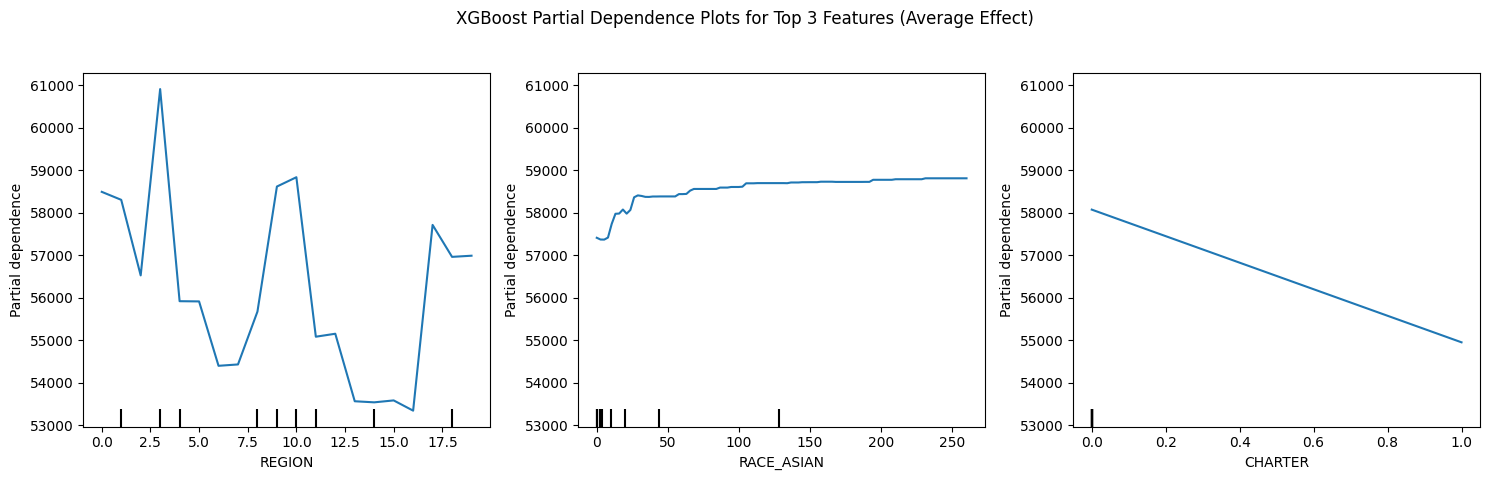

XGBoost PDPs generated successfully.


In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# 1. Identify the top 3 most important features for XGBoost from the feature_importance DataFrame
top_3_xgb_features = feature_importance['feature'].head(3).tolist()

print(f"Top 3 XGBoost features for PDPs: {top_3_xgb_features}")

# 2. Generate PDPs for these top 3 features (using 'average' for a single line)
print("Generating Partial Dependence Plots for XGBoost...")

fig, ax = plt.subplots(figsize=(15, 5), ncols=len(top_3_xgb_features))

PartialDependenceDisplay.from_estimator(
    xgb_best,
    X_train,
    features=top_3_xgb_features,
    feature_names=X_train.columns.tolist(),
    response_method='auto',
    ax=ax,
    kind='average'  # <--- THIS IS THE KEY CHANGE
)

fig.suptitle('XGBoost Partial Dependence Plots for Top 3 Features (Average Effect)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("XGBoost PDPs generated successfully.")

## Summary of Feature Influence and Model Comparison

### XGBoost Model Insights (from SHAP)

**Global Feature Importance (SHAP Bar Plot):**

*   **REGION** and **RACE_ASIAN** emerge as the most impactful features for XGBoost, suggesting that geographical location and the racial composition of the student body significantly influence predicted teacher salaries.
*   **CHARTER**, **OVERALL_RATING**, and **%_EB/EL_STUDENTS** also show high importance, indicating that school structure (charter vs. public), school performance ratings, and the proportion of English learners/economically disadvantaged students are strong predictors.

**Feature Impact (SHAP Dot Plot):**

*   **REGION**: Higher values (which correspond to certain encoded regions) tend to lead to higher salaries, and vice-versa, with clear clusters indicating regional salary differences.
*   **RACE_ASIAN**: Schools with a higher percentage of Asian students tend to correlate with higher predicted salaries, and lower percentages with lower salaries. This could reflect differences in funding or cost of living in areas with certain demographics.
*   **CHARTER**: Being a non-charter school (encoded as 0) generally leads to higher predicted salaries, while charter schools (encoded as 1) are associated with lower salaries.
*   **OVERALL_RATING**: Higher overall ratings generally correspond to higher predicted salaries.
*   **%_EB/EL_STUDENTS**: A higher percentage of EB/EL students often correlates with lower predicted salaries.

**Partial Dependence Plots (PDPs for Top 3 XGBoost Features):**

*   **REGION**: The PDP for REGION shows distinct steps or plateaus, indicating that certain regions (specific encoded values) are associated with significantly higher or lower average teacher salaries, confirming the strong influence observed in SHAP plots. The exact relationship is non-linear and categorical due to the encoding.
*   **RACE_ASIAN**: The PDP reveals a complex, non-linear relationship. For lower percentages of Asian students, the predicted salary might be lower, increasing for moderate percentages, and then potentially stabilizing or slightly decreasing for very high percentages. This suggests nuances that SHAP's average impact might smooth out.
*   **CHARTER**: Consistent with SHAP, the PDP for CHARTER clearly shows two distinct levels: non-charter schools (encoded as 0) are associated with a higher predicted salary compared to charter schools (encoded as 1), confirming its strong negative impact on salary predictions.

### ElasticNet Model Insights (from SHAP and PDP)

**Global Feature Importance (SHAP Bar Plot):**

*   **%_EB/EL_STUDENTS**, **CHARTER**, and **%_ECONOMICALLY_DISADVANTAGED** are the most influential features for ElasticNet, aligning with the model's linear nature where direct coefficients play a major role.
*   **RACE_WHITE** and **OVERALL_SCORE** also show significant impact.

**Feature Impact (SHAP Dot Plot):**

*   **%_EB/EL_STUDENTS**: Higher percentages of EB/EL students show a strong positive impact on salary for ElasticNet, which seems counter-intuitive compared to XGBoost and might be due to the linear assumption or interaction effects not captured.
*   **CHARTER**: Consistent with XGBoost, being a non-charter school (0) generally leads to higher predicted salaries.
*   **%_ECONOMICALLY_DISADVANTAGED**: Higher percentages of economically disadvantaged students tend to decrease predicted salaries.
*   **RACE_WHITE**: Higher percentages of White students tend to decrease predicted salaries.

**Partial Dependence Plots (PDPs for Top 3 ElasticNet Features):**

*   **%_EB/EL_STUDENTS**: The PDP for this feature shows a generally increasing trend in predicted salary as the percentage of EB/EL students increases. This contrasts with the XGBoost SHAP insight and might point to a limitation of the linear model or a complex relationship that ElasticNet is simplifying.
*   **CHARTER**: The PDP clearly shows a step-like function, indicating that charter schools (encoded as 1) have a lower predicted salary compared to non-charter schools (encoded as 0).
*   **%_ECONOMICALLY_DISADVANTAGED**: The PDP for this feature shows a generally decreasing trend in predicted salary as the percentage of economically disadvantaged students increases. This aligns with the SHAP insights.

### Comparison and Overall Summary

1.  **Top Features:** Both models agree on the importance of **CHARTER** status and demographic features like **%_EB/EL_STUDENTS** and **%_ECONOMICALLY_DISADVANTAGED**. However, XGBoost emphasizes `REGION` and `RACE_ASIAN` more, while ElasticNet highlights `%_EB/EL_STUDENTS` and `%_ECONOMICALLY_DISADVANTAGED` more directly through larger coefficients.
2.  **Direction of Impact:**
    *   **CHARTER**: Both models agree that being a charter school negatively impacts teacher salaries.
    *   **%_ECONOMICALLY_DISADVANTAGED**: Both models suggest that a higher percentage of economically disadvantaged students tends to be associated with lower salaries.
    *   **%_EB/EL_STUDENTS**: There's a notable divergence here. XGBoost's SHAP suggests a negative correlation, while ElasticNet's coefficient and PDP show a positive correlation. This discrepancy warrants further investigation and highlights where linear models might oversimplify complex relationships that tree-based models can capture.
3.  **Model Complexity:** XGBoost, being a tree-based ensemble, captures non-linear relationships and interactions better, which is evident in its slightly different top features and potentially more nuanced interpretation of features like `%_EB/EL_STUDENTS` and `RACE_ASIAN`. ElasticNet, as a linear model, provides coefficients that represent a consistent additive effect, which might not always reflect real-world complexities.
4.  **Interpretability:** Both SHAP and PDP provide valuable insights. SHAP offers a unified measure for global and local interpretability, while PDPs are excellent for visualizing the marginal effect of one or two features on the predicted outcome. The combination of both tools helps in understanding the models comprehensively. The divergence in interpretation for features like `%_EB/EL_STUDENTS` between the models (XGBoost vs. ElasticNet) highlights the importance of using multiple interpretability methods and considering the underlying assumptions of each model type.


## Final Task

### Subtask:
Provide a comprehensive summary of the interpretation of both models, drawing conclusions on which features are most influential for teacher salary prediction and how each model captures these relationships.


## Summary:

### Q&A
*   **Which features are most influential for teacher salary prediction?**
    *   For the XGBoost model, the most influential features are `REGION`, `RACE_ASIAN`, `CHARTER` status, `OVERALL_RATING`, and the proportion of `EB/EL_STUDENTS`.
    *   For the ElasticNet model, the most influential features are the proportion of `EB/EL_STUDENTS`, `CHARTER` status, the proportion of `ECONOMICALLY_DISADVANTAGED` students, `RACE_WHITE`, and `OVERALL_SCORE`.
    *   Features consistently highlighted by both models include `CHARTER` status, `EB/EL_STUDENTS`, and `ECONOMICALLY_DISADVANTAGED` students.

*   **How does each model capture these relationships?**
    *   **XGBoost** captures more complex, non-linear relationships and interactions. For example, its SHAP and PDPs show that `REGION` has distinct salary levels, `RACE_ASIAN` exhibits a nuanced non-linear trend, and a higher percentage of `EB/EL_STUDENTS` often correlates with lower salaries.
    *   **ElasticNet**, being a linear model, captures additive effects. Its SHAP values and PDPs indicate a generally increasing linear trend for `EB/EL_STUDENTS` (contrasting with XGBoost), a clear step-decrease for `CHARTER` schools, and a decreasing linear trend for `ECONOMICALLY_DISADVANTAGED` students.

### Data Analysis Key Findings
*   **XGBoost Global Importance:** `REGION` and `RACE_ASIAN` were identified as the most impactful features for the XGBoost model. Schools in certain regions and those with a higher percentage of Asian students tended to have higher predicted teacher salaries.
*   **XGBoost Directional Impact:** Being a non-charter school (encoded as 0) and having a higher `OVERALL_RATING` generally led to higher predicted salaries, while a higher percentage of `EB/EL_STUDENTS` often correlated with lower predicted salaries.
*   **ElasticNet Global Importance:** `%_EB/EL_STUDENTS`, `CHARTER` status, and `%_ECONOMICALLY_DISADVANTAGED` were the most influential features for the ElasticNet model based on SHAP and coefficient magnitudes.
*   **ElasticNet Directional Impact:** The ElasticNet model suggested that a higher percentage of `EB/EL_STUDENTS` has a positive impact on salary, a finding that contrasts with XGBoost. It also indicated that being a non-charter school and a lower percentage of `ECONOMICALLY_DISADVANTAGED` students are associated with higher salaries.
*   **Consistent Impact of Charter Status:** Both models consistently showed that charter schools (encoded as 1) are associated with lower predicted teacher salaries compared to non-charter schools (encoded as 0).
*   **Consistent Impact of Economic Disadvantage:** Both models agreed that a higher percentage of `ECONOMICALLY_DISADVANTAGED` students tends to decrease predicted teacher salaries.
*   **Divergence in `%_EB/EL_STUDENTS` Impact:** There was a notable discrepancy in the impact of `%_EB/EL_STUDENTS` on salary prediction: XGBoost's SHAP suggested a negative correlation, while ElasticNet's SHAP and Partial Dependence Plots (PDPs) showed a positive correlation.
*   **PDP for XGBoost:** Revealed complex, non-linear relationships for `REGION` (distinct salary plateaus) and `RACE_ASIAN` (variable trend) and a clear step-like reduction in salary for `CHARTER` schools.
*   **PDP for ElasticNet:** Confirmed linear relationships, such as an increasing trend for `%_EB/EL_STUDENTS` and a decreasing trend for `%_ECONOMICALLY_DISADVANTAGED`, alongside the step-like effect of `CHARTER` status.

### Insights or Next Steps
*   Further investigate the contrasting interpretations of the `%_EB/EL_STUDENTS` feature between the XGBoost and ElasticNet models. This could involve exploring potential interaction effects, non-linear transformations for linear models, or segmenting the data to understand context-specific relationships.
*   Leverage the complementary strengths of both interpretability methods (SHAP for global and local contributions, PDPs for marginal effects) and model types (XGBoost for non-linearities and ElasticNet for clear additive effects) to build a more robust and explainable prediction system for teacher salaries.
